In [109]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import TomekLinks
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import numpy as np
import random
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder

# pip install xgboost
from xgboost import XGBClassifier


In [110]:
df = pd.read_csv("winequality-red.csv")

### Train/test -split

In [111]:
X = df.drop("quality", axis=1)
y = df['quality']

In [112]:
categories = list(np.unique(df['quality']))


# encode the target from original 3, 4, 5, 6, 7, 8 to 0, 1, 2, 3, 4, 5
le = LabelEncoder()
y = le.fit_transform(y)

# stratify can be used to ensure data balance between train/test -datasets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y)


### XGBoost classifier

In [113]:
# create XGboost model
model = XGBClassifier(
    objective="multi:softmax",
    num_class=len(categories),
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8
)

# fit the model / start training
model.fit(X_train, y_train)

,objective,'multi:softmax'
,use_label_encoder,None
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


### Metrics

In [114]:
test_predictions = model.predict(X_test)

<Axes: >

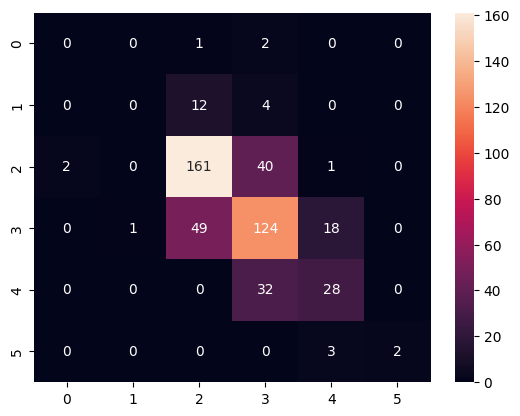

In [115]:
sns.heatmap(confusion_matrix(y_test, test_predictions), annot=True, fmt='g')


In [116]:
print(classification_report(y_test, test_predictions))

acc = accuracy_score(y_test, test_predictions)
print("\nModel overall accuracy: {:.2f}%".format(acc * 100))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       0.00      0.00      0.00        16
           2       0.72      0.79      0.75       204
           3       0.61      0.65      0.63       192
           4       0.56      0.47      0.51        60
           5       1.00      0.40      0.57         5

    accuracy                           0.66       480
   macro avg       0.48      0.38      0.41       480
weighted avg       0.63      0.66      0.64       480


Model overall accuracy: 65.62%
